In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Add this at the top of your notebook
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [2]:
from dataclasses import dataclass
from typing import Optional

import torch

@dataclass
class VAEOutput:
    """
    Dataclass for VAE output.
    
    Attributes:
        z_dist (torch.distributions.Distribution): The distribution of the latent variable z.
        z_sample (torch.Tensor): The sampled value of the latent variable z.
        x_recon (torch.Tensor): The reconstructed output from the VAE.
        loss (torch.Tensor): The overall loss of the VAE.
        loss_recon (torch.Tensor): The reconstruction loss component of the VAE loss.
        loss_kl (torch.Tensor): The KL divergence component of the VAE loss.
    """
    z_dist: torch.distributions.Distribution
    z_sample: torch.Tensor
    x_recon: torch.Tensor
    
    loss: Optional[torch.Tensor] = None
    loss_recon: Optional[torch.Tensor] = None
    loss_kl: Optional[torch.Tensor] = None

In [3]:
import lpips
import torch

# Create LPIPS model and move to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loss_fn_vgg = lpips.LPIPS(net='vgg').to(device)
loss_fn_vgg = torch.compile(loss_fn_vgg)

print(f"LPIPS model moved to device: {device}")

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
LPIPS model moved to device: cuda


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Optional

@dataclass
class VAEOutput:
    """Dataclass for VAE output."""
    z_dist: torch.distributions.Distribution
    z_sample: torch.Tensor
    x_recon: torch.Tensor
    loss: Optional[torch.Tensor] = None
    loss_recon: Optional[torch.Tensor] = None
    loss_kl: Optional[torch.Tensor] = None

class VAE(nn.Module):
    def __init__(self, input_channels: int, latent_channels: int, base_channels: int = 128):
        super().__init__()
        self.input_channels = input_channels
        self.latent_channels = latent_channels
        self.base_channels = base_channels

        # --- Encoder ---
        # Channels doubled: 64->128, 128->256, 256->512, 512->1024
        self.encoder = nn.Sequential(
            nn.Conv3d(input_channels, self.base_channels, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(self.base_channels), nn.SiLU(),
            nn.Conv3d(self.base_channels, self.base_channels * 2, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(self.base_channels * 2), nn.SiLU(),
            nn.Conv3d(self.base_channels * 2, self.base_channels * 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(self.base_channels * 4), nn.SiLU(),
            nn.Conv3d(self.base_channels * 4, self.base_channels * 8, kernel_size=(4, 3, 3), stride=(2, 1, 1), padding=(0, 1, 1)),
            nn.BatchNorm3d(self.base_channels * 8), nn.SiLU(),
            nn.Conv3d(self.base_channels * 8, 2 * self.latent_channels, kernel_size=3, stride=1, padding=1)
        )

        # --- Decoder ---
        # Channels doubled to mirror the encoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(self.latent_channels, self.base_channels * 8, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm3d(self.base_channels * 8), nn.SiLU(),
            nn.ConvTranspose3d(self.base_channels * 8, self.base_channels * 4, kernel_size=(4, 3, 3), stride=(2, 1, 1), padding=(0, 1, 1), output_padding=(1, 0, 0)),
            nn.BatchNorm3d(self.base_channels * 4), nn.SiLU(),
            nn.ConvTranspose3d(self.base_channels * 4, self.base_channels * 2, kernel_size=4, stride=2, padding=1, output_padding=(1, 0, 0)),
            nn.BatchNorm3d(self.base_channels * 2), nn.SiLU(),
            nn.ConvTranspose3d(self.base_channels * 2, self.base_channels, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1, output_padding=(0, 0, 0)),
            nn.BatchNorm3d(self.base_channels), nn.SiLU(),
            nn.ConvTranspose3d(self.base_channels, self.input_channels, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1, output_padding=(0, 0, 0)),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor, compute_loss: bool = True, beta: float = 1.0):
        latent_params = self.encoder(x)
        mu, logvar = torch.chunk(latent_params, 2, dim=1)
        dist = torch.distributions.Normal(mu, torch.exp(0.5 * logvar))
        z = dist.rsample()
        recon_x = self.decoder(z)

        if not compute_loss:
            return VAEOutput(z_dist=dist, z_sample=z, x_recon=recon_x)

        # L1 loss for 3D volumes
        l1_loss = nn.L1Loss(reduction='sum')
        l1_component = l1_loss(recon_x, x) / x.shape[0]
        
        # KL divergence
        #loss_kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=[1, 2, 3, 4]).mean()
        loss_kl = torch.mean(0.5 * torch.sum(torch.exp(logvar) + torch.pow(mu, 2) - 1. - logvar, dim=[1, 2, 3, 4]))

        
        return VAEOutput(
            z_dist=dist, z_sample=z, x_recon=recon_x,
            loss=None, loss_recon=l1_component, loss_kl=loss_kl,
        )

def compute_lpips_loss(recon_x, x, lpips_model):
    B, C, D, H, W = recon_x.shape
    chunk_size = 2
    slice_losses = []
    
    for b in range(B):
        volume_losses = []
        recon_volume = recon_x[b]
        x_volume = x[b]
        
        recon_slices = recon_volume.permute(1, 0, 2, 3)
        x_slices = x_volume.permute(1, 0, 2, 3)
        
        for i in range(0, D, chunk_size):
            end_idx = min(i + chunk_size, D)
            recon_chunk = recon_slices[i:end_idx]
            x_chunk = x_slices[i:end_idx]
            
            with torch.no_grad():
                chunk_losses = lpips_model(recon_chunk, x_chunk)
                # Fix: Don't squeeze if it would make tensor 0-dimensional
                if chunk_losses.dim() > 0:
                    chunk_losses = chunk_losses.squeeze()
                # Ensure we always have at least 1 dimension
                if chunk_losses.dim() == 0:
                    chunk_losses = chunk_losses.unsqueeze(0)
                volume_losses.append(chunk_losses.detach())
            
            # Only clear cache every few chunks, not every chunk
            if i % (chunk_size * 4) == 0:
                torch.cuda.empty_cache()
        
        # Concatenate and take mean
        volume_loss = torch.cat(volume_losses, dim=0).mean()
        slice_losses.append(volume_loss)
    
    return torch.stack(slice_losses).mean()

In [5]:
import torchvision.datasets as datasets

In [6]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset

class GermariumDataset(Dataset):
    """
    Ultra-simplified dataset for standardized volume folders.
    Expects folders named 'volume_XXXX' containing files 1.tif through 15.tif
    """
    def __init__(self, standardized_dir, transform=None):
        """
        Args:
            standardized_dir: Directory containing standardized volume_XXXX folders
            transform: Optional transform to be applied on a sample
        """
        self.standardized_dir = standardized_dir
        self.transform = transform
        
        # Get all volume directories (sorted for consistent ordering)
        self.volume_dirs = sorted([
            d for d in os.listdir(standardized_dir) 
            if os.path.isdir(os.path.join(standardized_dir, d)) and d.startswith('volume_')
        ])
        
        print(f"GermariumDataset loaded {len(self.volume_dirs)} volumes")
    
    def __len__(self):
        return len(self.volume_dirs)
    
    def __getitem__(self, idx):
        volume_dir = os.path.join(self.standardized_dir, self.volume_dirs[idx])
        
        # Load exactly 15 files: 1.tif through 15.tif
        frames = []
        for i in range(1, 16):
            img_path = os.path.join(volume_dir, f'{i}.tif')
            img = Image.open(img_path).convert('RGB')
            frame_array = np.array(img)
            
            frames.append(frame_array)
        
        # Stack frames: (slices, H, W, C)
        volume = np.stack(frames, axis=0)
        
        # Convert to tensor and normalize
        volume = torch.from_numpy(volume).float() / 255.0
        
        # Rearrange to (C, slices, H, W) for 3D convolutions
        volume = volume.permute(3, 0, 1, 2)
        
        #if self.transform:
            #volume = self.transform(volume)
        
        return volume

In [ ]:
# Example: Using the new SuperSimple dataset for training
from sklearn.model_selection import train_test_split

# The standardized directory path (from the standardization process above)
standardized_path = 'data/standardized_volumes'

# Create the ultra-simple dataset
print("Creating dataset...")
full_dataset = GermariumDataset(standardized_path)

# Split indices for train/test (80/20 split)
train_indices, test_indices = train_test_split(
    range(len(full_dataset)), 
    test_size=0.2, 
    random_state=42
)

print(f"Dataset split: {len(train_indices)} train, {len(test_indices)} test samples")

# Create data loaders (much simpler now!)
from torch.utils.data import Subset, DataLoader

train_dataset = Subset(full_dataset, train_indices)
test_dataset = Subset(full_dataset, test_indices)

batch_size = 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

print(f"Created data loaders:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test loading a batch
sample_batch = next(iter(train_loader))
print(f"  Batch shape: {sample_batch.shape}")
print(f"  Batch range: [{sample_batch.min():.3f}, {sample_batch.max():.3f}]")

Creating dataset...
GermariumDataset loaded 348 volumes
Dataset split: 278 train, 70 test samples
Created data loaders:
  Train batches: 139
  Test batches: 35


In [ ]:
for i in range(0, len(full_dataset)):
    assert full_dataset[1].shape == torch.Size([3, 15, 512, 512])

print("all images are the same size")

all images are the same size


In [ ]:
learning_rate = 1e-4
weight_decay = 1e-3
latent_channels = 64

In [ ]:
from datetime import datetime

import torch
from torch.utils.tensorboard import SummaryWriter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE(input_channels=3, latent_channels=latent_channels, base_channels=128).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
writer = SummaryWriter(f'runs/germarium/vae_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

2025-07-25 05:17:15.234867: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-25 05:17:15.242297: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753435035.249001   56808 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753435035.251062   56808 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753435035.256810   56808 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [11]:
model

VAE(
  (encoder): Sequential(
    (0): Conv3d(3, 128, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1))
    (1): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Conv3d(128, 256, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1))
    (4): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU()
    (6): Conv3d(256, 512, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (7): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): SiLU()
    (9): Conv3d(512, 1024, kernel_size=(4, 3, 3), stride=(2, 1, 1), padding=(0, 1, 1))
    (10): BatchNorm3d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): SiLU()
    (12): Conv3d(1024, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose3d(64, 1024, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding

In [12]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 63028611


In [13]:
for name, param in model.named_parameters():
    print(f"{name}: {param.numel()} parameters, requires_grad={param.requires_grad}")

encoder.0.weight: 18432 parameters, requires_grad=True
encoder.0.bias: 128 parameters, requires_grad=True
encoder.1.weight: 128 parameters, requires_grad=True
encoder.1.bias: 128 parameters, requires_grad=True
encoder.3.weight: 1572864 parameters, requires_grad=True
encoder.3.bias: 256 parameters, requires_grad=True
encoder.4.weight: 256 parameters, requires_grad=True
encoder.4.bias: 256 parameters, requires_grad=True
encoder.6.weight: 8388608 parameters, requires_grad=True
encoder.6.bias: 512 parameters, requires_grad=True
encoder.7.weight: 512 parameters, requires_grad=True
encoder.7.bias: 512 parameters, requires_grad=True
encoder.9.weight: 18874368 parameters, requires_grad=True
encoder.9.bias: 1024 parameters, requires_grad=True
encoder.10.weight: 1024 parameters, requires_grad=True
encoder.10.bias: 1024 parameters, requires_grad=True
encoder.12.weight: 3538944 parameters, requires_grad=True
encoder.12.bias: 128 parameters, requires_grad=True
decoder.0.weight: 1769472 parameters, 

In [14]:
# --- Check the latent shape ---
dummy_data = torch.randn(2, 3, 15, 512, 512).to(device)
output = model(dummy_data, compute_loss=False)
z_sample_shape = output.z_sample.shape

print(f"Latent space 'z' shape: {z_sample_shape}")

Latent space 'z' shape: torch.Size([2, 64, 2, 64, 64])


In [15]:
dummy = torch.randn(2, 3, 15, 512, 512).to(device)
model.eval()
with torch.no_grad():
    out = model(dummy, compute_loss=False)
    print('Input shape:', dummy.shape)
    print('Output shape:', out.x_recon.shape)
assert out.x_recon.shape == dummy.shape, f'Shape mismatch: {out.x_recon.shape} vs {dummy.shape}'
print('Shape test passed!')

Input shape: torch.Size([2, 3, 15, 512, 512])
Output shape: torch.Size([2, 3, 15, 512, 512])
Shape test passed!


In [ ]:
from tqdm import tqdm

def get_kl_weight(epoch, total_epochs, boost_epoch, start_epoch=0, num_cycles=4, ratio=0.5):
    """
    Calculates the KL weight using a cyclical linear schedule.
    
    Args:
        epoch (int): The current epoch.
        total_epochs (int): The total number of epochs for training.
        boost_epoch (int): Epoch after which to apply boost multiplier.
        start_epoch (int): Epoch to start the KL weight schedule.
        num_cycles (int): The number of cycles to complete.
        ratio (float): The proportion of a cycle used for ramping up beta.
    """
    
    if epoch < start_epoch:
        return 0.0007

    # Adjust epoch relative to start_epoch
    adjusted_epoch = epoch - start_epoch
    epoch_per_cycle = (total_epochs - start_epoch) / num_cycles
    
    # The current position within the cycle (from 0 to epoch_per_cycle)
    current_pos_in_cycle = adjusted_epoch % epoch_per_cycle
    
    # The point in the cycle where beta should reach 1.0
    ramp_up_end = epoch_per_cycle * ratio
    
    if current_pos_in_cycle < ramp_up_end:
        # Linearly increase the weight from 0 to 1 during ramp-up phase
        base_weight = current_pos_in_cycle / ramp_up_end
        
        if epoch < boost_epoch:
            # Before boost epoch, use reduced weight
            return base_weight * 0.01
        else:
            # After boost epoch, apply boost multiplier
            boost_multiplier = min(2, epoch / boost_epoch)
            return min(2, base_weight * boost_multiplier)
    else:
        # Constant phase of the cycle
        if epoch < boost_epoch:
            return 0.01
        else:
            return 1.25


from tqdm import tqdm

def train(model, dataloader, optimizer, prev_updates, beta, writer=None):
    """
    Trains the model on the given data with external LPIPS computation.
    """
    model.train()  # Set the model to training mode
    
    for batch_idx, data in enumerate(tqdm(dataloader)):
        n_upd = prev_updates + batch_idx
        
        data = data.to(device)
        
        optimizer.zero_grad()  # Zero the gradients
        
        # Forward pass (without LPIPS in the compiled model)
        output = model(data, beta=beta)
        
        # Compute LPIPS loss externally
        lpips_component = compute_lpips_loss(output.x_recon, data, loss_fn_vgg)
        
        # Combine losses with weighting
        loss_recon = 0.3 * output.loss_recon + 0.7 * lpips_component
        loss = loss_recon + beta * output.loss_kl
        
        loss.backward()
        
        if n_upd % 100 == 0:
            # Calculate and log gradient norms
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** (1. / 2)
        
            print(f'Step {n_upd:,} (N samples: {n_upd*batch_size:,}), Loss: {loss.item():.4f} (Recon: {loss_recon.item():.4f}, KL: {output.loss_kl.item():.4f}) Grad: {total_norm:.4f}')

            if writer is not None:
                global_step = n_upd
                writer.add_scalar('Loss/Train', loss.item(), global_step)
                writer.add_scalar('Loss/Train/Recon', loss_recon.item(), global_step)
                writer.add_scalar('Loss/Train/KLD', output.loss_kl.item(), global_step)
                writer.add_scalar('GradNorm/Train', total_norm, global_step)
            
        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)    
        
        optimizer.step()  # Update the model parameters
        
    return prev_updates + len(dataloader)

In [ ]:
from torchvision.utils import make_grid
from tqdm import tqdm

def test(model, dataloader, cur_step, latent_channels, writer=None):
    """
    Tests the model on the given data with external LPIPS computation.
    
    Args:
        model (nn.Module): The model to test.
        dataloader (torch.utils.data.DataLoader): The data loader.
        cur_step (int): The current training step.
        latent_channels (int): The number of channels in the latent space.
        writer: The TensorBoard writer.
    """
    model.eval()
    test_loss = 0
    test_recon_loss = 0
    test_kl_loss = 0
    bce_loss = 0
    
    with torch.no_grad():
        # Get the last batch for visualization purposes
        for data in tqdm(dataloader, desc='Testing'):
            data = data.to(device)
            
            # Forward pass (without LPIPS in the compiled model)
            output = model(data, compute_loss=True)
            
            # Compute LPIPS loss externally (same as in training)
            lpips_component = compute_lpips_loss(output.x_recon, data, loss_fn_vgg)
            bce = F.binary_cross_entropy(output.x_recon, data, reduction='sum') / data.shape[0]
            
            # Combine losses with weighting (same as in training)
            loss_recon = 0.3 * output.loss_recon + 0.7 * lpips_component
            loss = loss_recon + output.loss_kl  # Using beta=1 for testing
            
            test_loss += loss.item()
            test_recon_loss += loss_recon.item()
            test_kl_loss += output.loss_kl.item()
            bce_loss += bce.item()
            
    # Calculate average losses
    test_loss /= len(dataloader)
    test_recon_loss /= len(dataloader)
    test_kl_loss /= len(dataloader)
    bce_loss /= len(dataloader)

    print(f'====> Test set loss: {test_loss:.4f} (Recon: {test_recon_loss:.4f}, KLD: {test_kl_loss:.4f})')
    
    if writer is not None:
        # Log scalar losses
        writer.add_scalar('Loss/Test', test_loss, global_step=cur_step)
        writer.add_scalar('Loss/Test/Recon', test_recon_loss, global_step=cur_step)
        writer.add_scalar('Loss/Test/KLD', test_kl_loss, global_step=cur_step)
        writer.add_scalar('Loss/Test/BCE', bce_loss, global_step=cur_step)
        
        # --- Log Reconstructions and Originals ---
        # Take the first volume from the last batch for visualization
        recon_volume = output.x_recon[0]
        orig_volume = data[0]

        # Create a grid of all 15 slices from the volume
        recon_grid = make_grid(recon_volume.permute(1, 0, 2, 3), nrow=5, normalize=True)
        orig_grid = make_grid(orig_volume.permute(1, 0, 2, 3), nrow=5, normalize=True)
        
        writer.add_image('Test/Reconstruction Slices', recon_grid, global_step=cur_step)
        writer.add_image('Test/Original Slices', orig_grid, global_step=cur_step)
        
        # --- Log a Generated Sample Grid ---
        # Create a random latent tensor with a batch size of 1
        z = torch.randn(1, latent_channels, 2, 16, 16).to(device)
        
        # Generate a sample by passing the latent tensor directly to the decoder
        sample = model.decoder(z)
        
        # Create a grid of all 15 slices from the generated volume
        sample_grid = make_grid(sample[0].permute(1, 0, 2, 3), nrow=5, normalize=True)
        writer.add_image('Test/Generated Sample Slices', sample_grid, global_step=cur_step)

In [ ]:
model = torch.compile(model)

In [ ]:
torch.backends.cudnn.benchmark = True

In [ ]:
print(torch.backends.cudnn.benchmark)

True


In [21]:
#example_forward_input = torch.randn(1, latent_channels, 2, 16, 16).to(device)
#traced_module = torch.jit.trace(model, example_forward_input)

In [ ]:
prev_updates = 0
num_epochs = 300

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    beta = get_kl_weight(epoch, num_epochs, boost_epoch=250, start_epoch=150)
    if writer:  
        writer.add_scalar('Train/KL_Weight (beta)', beta, epoch)
    prev_updates = train(model, train_loader, optimizer, prev_updates, beta, writer=writer)
    test(model, test_loader, prev_updates, latent_channels, writer=writer)

Epoch 1/300


  0%|          | 0/139 [00:00<?, ?it/s]

In [ ]:
model_save_path = 'vae_germarium_model_3d_perceptual_loss_overnight.pth'
torch.save({
            'epoch': num_epochs,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            }, model_save_path)

print(f"\nModel saved to {model_save_path}")

In [ ]:
torch.save(model, "full_model.pth")

In [ ]:
image = test_dataset[0].to(device).unsqueeze(0)
output = model(image, compute_loss=True)

recon_volume = output.x_recon[0]
orig_volume = image[0]

# Create a grid of all 15 slices from the volume
recon_grid = make_grid(recon_volume.permute(1, 0, 2, 3), nrow=5, normalize=True)
orig_grid = make_grid(orig_volume.permute(1, 0, 2, 3), nrow=5, normalize=True)

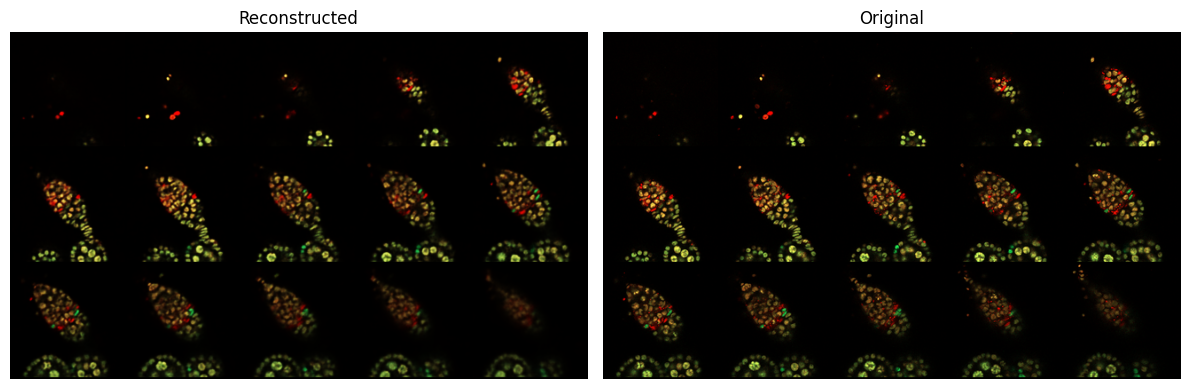

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot reconstruction
axes[0].imshow(recon_grid.permute(1, 2, 0).cpu())
axes[0].set_title('Reconstructed')
axes[0].axis('off')

# Plot original
axes[1].imshow(orig_grid.permute(1, 2, 0).cpu())
axes[1].set_title('Original')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from skimage.metrics import peak_signal_noise_ratio
from pytorch_msssim import ssim, ms_ssim, SSIM, MS_SSIM

psnr = peak_signal_noise_ratio(orig_volume.detach().cpu().numpy(), recon_volume.detach().cpu().numpy(), data_range=1.0)
ssim_val = ssim(orig_volume.unsqueeze(0), recon_volume.unsqueeze(0), data_range=1.0, size_average=False) # return (N,)
lpips_loss = compute_lpips_loss(orig_volume.unsqueeze(0), recon_volume.unsqueeze(0), loss_fn_vgg)

ms_ssim_val = ms_ssim(orig_volume.unsqueeze(0), recon_volume.unsqueeze(0), data_range=1.0, size_average=False, win_size=7) # return (N,)

#ssim = structural_similarity(orig_volume.detach().cpu().numpy(), recon_volume.detach().cpu().numpy(), multichannel=True)

/home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/pytorch_msssim/ssim.py:50: UserWarning: Skipping Gaussian Smoothing at dimension 2+0 for input: torch.Size([1, 3, 4, 32, 32]) and win size: 7
  warnings.warn(
/home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/pytorch_msssim/ssim.py:50: UserWarning: Skipping Gaussian Smoothing at dimension 2+0 for input: torch.Size([1, 3, 2, 16, 16]) and win size: 7
  warnings.warn(
/home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/pytorch_msssim/ssim.py:50: UserWarning: Skipping Gaussian Smoothing at dimension 2+0 for input: torch.Size([1, 3, 1, 8, 8]) and win size: 7
  warnings.warn(


In [ ]:
print("psnr: ", psnr.item())
print("ssim: ", ssim_val.item())
print("ms_ssim: ", ms_ssim_val.item())
print("perceptual loss: ", lpips_loss.item())

psnr:  32.42757604885577
ssim:  0.9629319906234741
ms_ssim:  0.991515040397644
perceptual loss:  0.05708544701337814


In [ ]:
model_save_path = 'vae_germarium_model_3d_perceptual_loss_overnight.pth'
torch.save({
            'epoch': num_epochs,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            }, model_save_path)

print(f"\nModel saved to {model_save_path}")


Model saved to vae_germarium_model_3d_perceptual_loss.pth


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Optional

@dataclass
class VAEOutput:
    """Dataclass for VAE output."""
    z_dist: torch.distributions.Distribution
    z_sample: torch.Tensor
    x_recon: torch.Tensor
    loss: Optional[torch.Tensor] = None
    loss_recon: Optional[torch.Tensor] = None
    loss_kl: Optional[torch.Tensor] = None

class VAE(nn.Module):
    def __init__(self, input_channels: int, latent_channels: int):
        super().__init__()
        self.input_channels = input_channels
        self.latent_channels = latent_channels

        # --- Encoder ---
        self.encoder = nn.Sequential(
            # Input: (B, 3, 15, 256, 256) -> Block 1: (15, 128, 128)
            nn.Conv3d(input_channels, 32, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(32), nn.SiLU(),
            # Block 2: -> (15, 64, 64)
            nn.Conv3d(32, 64, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1),
            nn.BatchNorm3d(64), nn.SiLU(),
            # Block 3: -> (7, 32, 32)
            nn.Conv3d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(128), nn.SiLU(),
            # Block 4: -> (3, 16, 16)
            nn.Conv3d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(256), nn.SiLU(),
            # Block 5: -> (1, 16, 16) - Note stride is (2,1,1)
            nn.Conv3d(256, 256, kernel_size=3, stride=(2, 1, 1), padding=1),
            nn.BatchNorm3d(256), nn.SiLU(),
            # Block 6: Final layer outputs latent parameters
            nn.Conv3d(256, 2 * self.latent_channels, kernel_size=3, stride=1, padding=1)
        )

        # --- Decoder ---
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(self.latent_channels, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm3d(256), nn.SiLU(),
            nn.ConvTranspose3d(256, 256, kernel_size=3, stride=(2, 1, 1), padding=1, output_padding=(0,0,0)),
            nn.BatchNorm3d(256), nn.SiLU(),
            nn.ConvTranspose3d(256, 128, kernel_size=4, stride=2, padding=1, output_padding=(1,0,0)),
            nn.BatchNorm3d(128), nn.SiLU(),
            nn.ConvTranspose3d(128, 64, kernel_size=4, stride=2, padding=1, output_padding=(1, 0, 0)),
            nn.BatchNorm3d(64), nn.SiLU(),
            nn.ConvTranspose3d(64, 32, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.BatchNorm3d(32), nn.SiLU(),
            nn.ConvTranspose3d(32, self.input_channels, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1)),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor, compute_loss: bool = True, beta: float = 1.0):
        latent_params = self.encoder(x)
        mu, logvar = torch.chunk(latent_params, 2, dim=1)
        dist = torch.distributions.Normal(mu, torch.exp(0.5 * logvar))
        z = dist.rsample()
        recon_x = self.decoder(z)

        if not compute_loss:
            return VAEOutput(z_dist=dist, z_sample=z, x_recon=recon_x)

        loss_recon = F.binary_cross_entropy(recon_x, x, reduction='sum') / x.shape[0]
        loss_kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=[1, 2, 3, 4]).mean()
        loss = loss_recon + beta * loss_kl

        return VAEOutput(
            z_dist=dist, z_sample=z, x_recon=recon_x,
            loss=loss, loss_recon=loss_recon, loss_kl=loss_kl,
        )

In [ ]:
# Load the saved model and continue training
import torch
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

# Load the saved model
model_load_path = 'vae_germarium_model_3d_perceptual_loss_300epochs.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Recreate the model
model = VAE(input_channels=3, latent_channels=latent_channels).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Load the checkpoint
checkpoint = torch.load(model_load_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']

print(f"Model loaded from {model_load_path}")
print(f"Resuming training from epoch {start_epoch}")

# Create a new tensorboard writer for continued training
writer = SummaryWriter(f'runs/germarium/vae_continued_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

Model loaded from vae_germarium_model_3d_continued_1300epochs.pth
Resuming training from epoch 1300


In [ ]:
output = model(image, compute_loss=True)
recon_volume = output.x_recon[0]
orig_volume = image[0]

psnr = peak_signal_noise_ratio(orig_volume.detach().cpu().numpy(), recon_volume.detach().cpu().numpy(), data_range=1.0)
ssim_val = ssim(orig_volume.unsqueeze(0), recon_volume.unsqueeze(0), data_range=1.0, size_average=False) # return (N,)
lpips_loss = compute_lpips_loss(orig_volume.unsqueeze(0), recon_volume.unsqueeze(0), loss_fn_vgg)

ms_ssim_val = ms_ssim(orig_volume.unsqueeze(0), recon_volume.unsqueeze(0), data_range=1.0, size_average=False, win_size=7) # return (N,)

#ssim = structural_similarity(orig_volume.detach().cpu().numpy(), recon_volume.detach().cpu().numpy(), multichannel=True)

/home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/pytorch_msssim/ssim.py:50: UserWarning: Skipping Gaussian Smoothing at dimension 2+0 for input: torch.Size([1, 3, 4, 32, 32]) and win size: 7
  warnings.warn(
/home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/pytorch_msssim/ssim.py:50: UserWarning: Skipping Gaussian Smoothing at dimension 2+0 for input: torch.Size([1, 3, 2, 16, 16]) and win size: 7
  warnings.warn(
/home/sam/miniconda3/envs/biovision/lib/python3.12/site-packages/pytorch_msssim/ssim.py:50: UserWarning: Skipping Gaussian Smoothing at dimension 2+0 for input: torch.Size([1, 3, 1, 8, 8]) and win size: 7
  warnings.warn(


In [ ]:
print("psnr: ", psnr.item())
print("ssim: ", ssim_val.item())
print("ms_ssim: ", ms_ssim_val.item())
print("perceptual loss: ", lpips_loss.item())

psnr:  33.00781466638031
ssim:  0.9711889624595642
ms_ssim:  0.9942459464073181
perceptual loss:  0.04148146137595177


In [ ]:
# Continue training for additional epochs
additional_epochs = 1000  # Adjust this as needed
total_epochs = start_epoch + additional_epochs
prev_updates = start_epoch * len(train_loader)  # Approximate previous updates

print(f"Training for {additional_epochs} additional epochs (up to epoch {total_epochs})")

for epoch in range(start_epoch, total_epochs):
    print(f'Epoch {epoch+1}/{total_epochs}')
    beta = 1
    if writer:  
        writer.add_scalar('Train/KL_Weight (beta)', beta, epoch)
    prev_updates = train(model, train_loader, optimizer, prev_updates, beta, writer=writer)
    test(model, test_loader, prev_updates, latent_channels, writer=writer)

# Save the updated model
updated_model_path = f'vae_germarium_model_3d_continued_{total_epochs}epochs.pth'
torch.save({
    'epoch': total_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, updated_model_path)

print(f"\nUpdated model saved to {updated_model_path}")
writer.close()

Training for 1000 additional epochs (up to epoch 1300)
Epoch 301/1300


 11%|█         | 1/9 [00:00<00:04,  1.68it/s]

Step 2,700 (N samples: 172,800), Loss: 60878.7148 (Recon: 60816.8203, KL: 711.7647) Grad: 7067.6710


Testing: 100%|██████████| 3/3 [00:00<00:00,  5.11it/s]



====> Test set loss: 62790.2409 (BCE: 61375.1940, KLD: 1415.0462)
Epoch 302/1300
Epoch 302/1300


...

Testing: 100%|██████████| 3/3 [00:00<00:00,  5.18it/s]



====> Test set loss: 61788.4323 (BCE: 61206.5638, KLD: 581.8678)
Epoch 537/1300
Epoch 537/1300


Testing: 100%|██████████| 3/3 [00:00<00:00,  5.01it/s]


====> Test set loss: 61905.8880 (BCE: 61306.5547, KLD: 599.3329)
Epoch 538/1300
Epoch 538/1300


 67%|██████▋   | 6/9 [00:02<00:01,  2.71it/s]

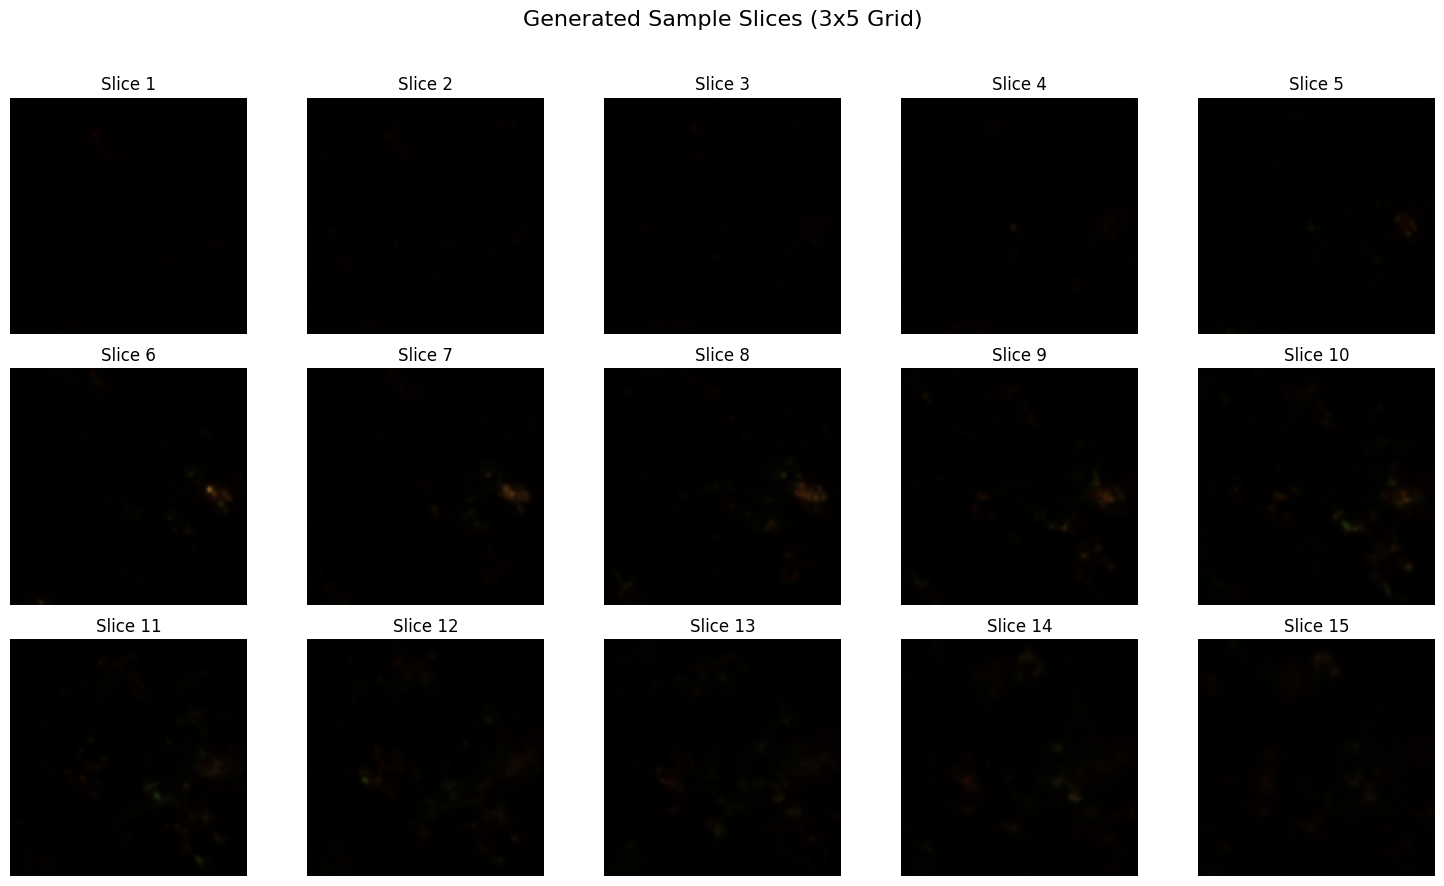

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Ensure you have the VAE_16x16_Latent class definition available here ---
# (from the previous response)

# --- Parameters ---
# IMPORTANT: These must match the parameters of the saved model.
latent_channels = 16
input_channels = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Load the Model ---
# 1. Instantiate the model with the correct class name
loaded_model = VAE(
    input_channels=input_channels,
    latent_channels=latent_channels
).to(device)
loaded_model = torch.compile(loaded_model)

# 2. Load the checkpoint
checkpoint = torch.load('vae_germarium_model_3d_large.pth', map_location=device)

# --- Generate Sample ---
model.eval() # Ensure model is in eval mode
with torch.no_grad():
    # Create a random latent tensor with a batch size of 1
    z = torch.randn(1, latent_channels, 2, 16, 16).to(device)
    
    # 3. Generate a sample by passing the latent tensor directly to the decoder
    sample = model.decoder(z)

# --- Plotting (No changes needed here) ---
# Convert to numpy for plotting
# sample shape: (1, C, D, H, W) -> (1, 3, 15, 256, 256)
sample_volume = sample.cpu().numpy()[0] # Get the first (and only) volume in the batch
# sample_volume shape: (C, D, H, W) -> (3, 15, 256, 256)

# Create a 3x5 grid for the 15 slices
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Generated Sample Slices (3x5 Grid)', fontsize=16)

for i in range(15):
    row = i // 5
    col = i % 5
    ax = axes[row, col]
    
    # Get the i-th slice and transpose from (C, H, W) to (H, W, C) for matplotlib
    img_slice = sample_volume[:, i, :, :].transpose(1, 2, 0)
    
    # Clip values to [0, 1] range for valid image display
    img_slice = np.clip(img_slice, 0, 1)
    
    ax.imshow(img_slice)
    ax.set_title(f'Slice {i+1}')
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
plt.savefig('vae_germarium_sample_slices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def plot_grid(sample_volume):
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    fig.suptitle('Generated Sample Slices (3x5 Grid)', fontsize=16)

    for i in range(15):
        row = i // 5
        col = i % 5
        ax = axes[row, col]
        
        # Get the i-th slice and transpose from (C, H, W) to (H, W, C) for matplotlib
        img_slice = sample_volume[:, i, :, :].transpose(1, 2, 0)
        
        # Clip values to [0, 1] range for valid image display
        img_slice = np.clip(img_slice, 0, 1)
        
        ax.imshow(img_slice)
        ax.set_title(f'Slice {i+1}')
        ax.axis('off')

In [ ]:
type(sample_volume)

numpy.ndarray

In [ ]:
vol.numpy().shape

(3, 15, 128, 128)

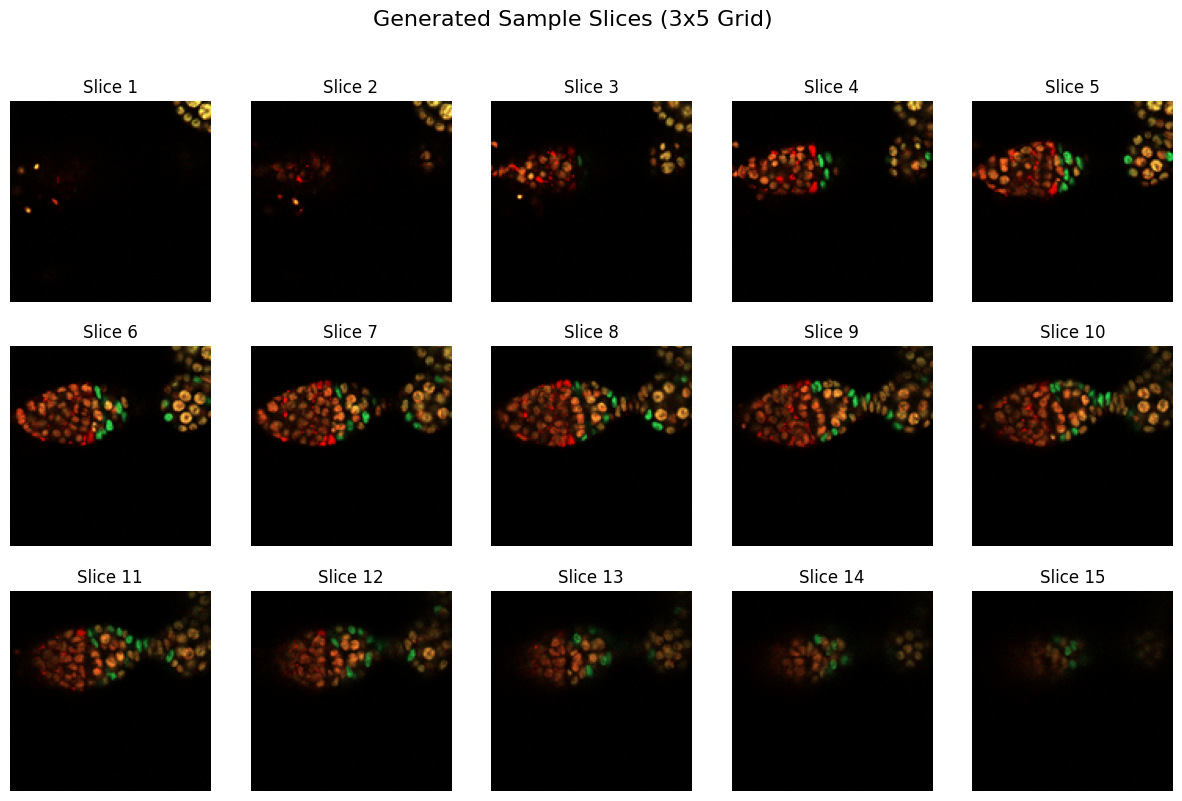

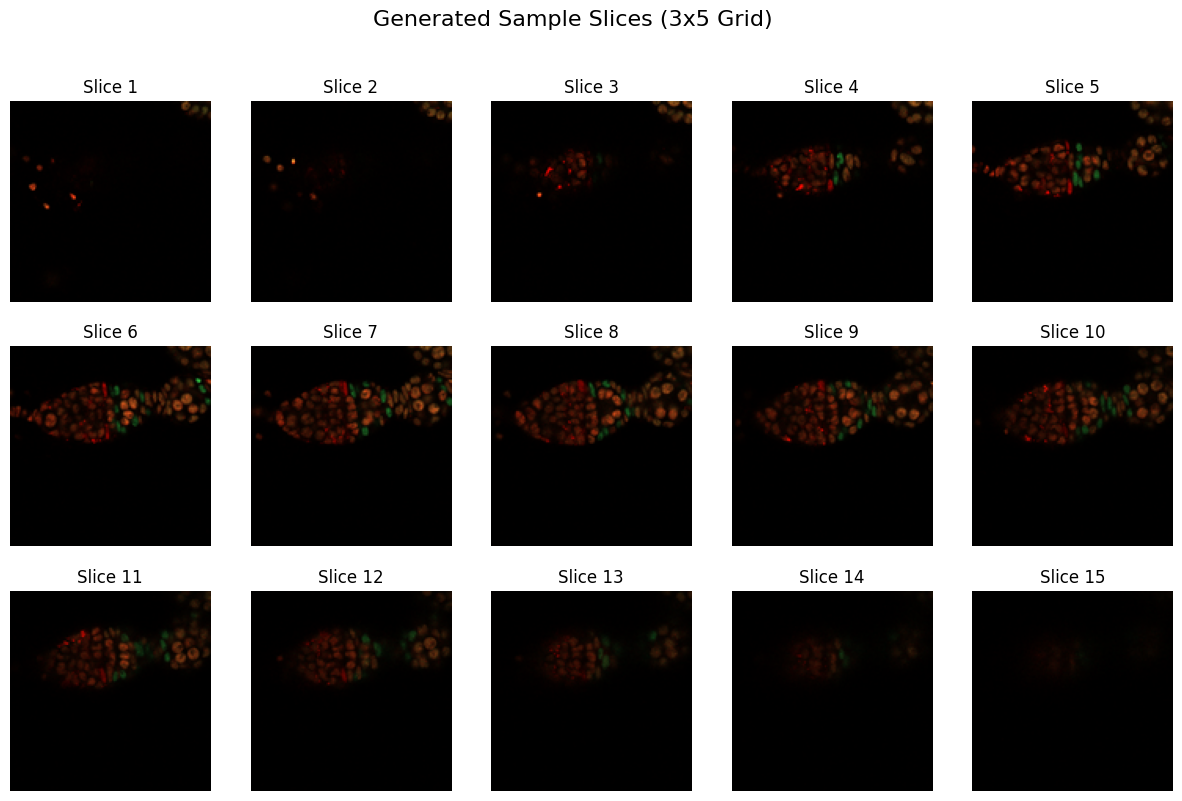

In [ ]:
vol1 = full_dataset[0]
vol2 = full_dataset[30]
plot_grid(vol1.numpy())
plot_grid(vol2.numpy())

In [ ]:
def interpolate_latent_space():
    # --- Parameters ---
    latent_channels = 16
    input_channels = 3
    model_path = 'vae_germarium_model_3d_large.pth'
    # IMPORTANT: Update this path to where your data is located
    # Using a placeholder path here.
    standardized_path = '/home/sam/dev/BioVision/VAE/data/standardized_volumes_128x128' 
    num_steps = 10  # Number of interpolation steps between the two points
    start_idx = 0   # Index of the first image in the dataset
    end_idx = 30    # Index of the second image in the dataset

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # --- Load Model ---
    if not os.path.exists(model_path):
        print(f"Error: Model file not found at '{model_path}'")
        print("Please ensure the model is trained and saved with this filename.")
        return

    model = VAE(input_channels=input_channels, latent_channels=latent_channels).to(device)
    model = torch.compile(model)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print("Model loaded successfully.")

    # --- Load Data ---
    if not os.path.isdir(standardized_path):
        print(f"Error: Dataset directory not found at '{standardized_path}'")
        print("Please update the 'standardized_path' variable with the correct location.")
        return
        
    dataset = GermariumDataset(standardized_path)
    if len(dataset) <= end_idx:
        print(f"Error: end_idx ({end_idx}) is out of bounds for the dataset size ({len(dataset)}).")
        return

    # --- Get Start and End Points ---
    # Get two volumes from the dataset and add a batch dimension
    x_a = dataset[start_idx].unsqueeze(0).to(device)
    x_b = dataset[end_idx].unsqueeze(0).to(device)

    # --- Encode to Latent Space ---
    with torch.no_grad():
        # We use the mean (mu) of the distribution as our latent representation
        mu_a, _ = torch.chunk(model.encoder(x_a), 2, dim=1)
        mu_b, _ = torch.chunk(model.encoder(x_b), 2, dim=1)

    # --- Interpolate ---
    interpolated_latents = []
    alpha_values = torch.linspace(0, 1, num_steps)

    for alpha in alpha_values:
        # Linear interpolation: z = (1-alpha)*z_a + alpha*z_b
        z_inter = (1 - alpha) * mu_a + alpha * mu_b
        interpolated_latents.append(z_inter)
    
    # Stack all interpolated vectors into a single tensor
    z_inter_tensor = torch.cat(interpolated_latents, dim=0).to(device)

    # --- Decode Back to Image Space ---
    with torch.no_grad():
        generated_volumes = model.decoder(z_inter_tensor)

    # --- Visualization ---
    # Prepare original and generated volumes for plotting
    volumes_to_plot = [x_a] + list(torch.chunk(generated_volumes, num_steps, dim=0)) + [x_b]
    titles = ['Original A'] + [f'Step {i+1}' for i in range(num_steps)] + ['Original B']
    
    # Create a plot for each volume, with its slices arranged in a 3x5 grid
    num_volumes = len(volumes_to_plot)
    # Adjust figsize for a more compact 3x5 grid layout
    fig, axes = plt.subplots(num_volumes, 1, figsize=(10, 7 * num_volumes))
    fig.suptitle('Latent Space Interpolation (3x5 Grids)', fontsize=20, y=1.0)

    # If there's only one plot, plt.subplots returns a single Axes object, not an array
    if num_volumes == 1:
        axes = [axes]

    for i, (vol_tensor, title) in enumerate(zip(volumes_to_plot, titles)):
        # Remove batch dimension, permute to (D, C, H, W) for make_grid
        vol_for_grid = vol_tensor.squeeze(0).cpu().permute(1, 0, 2, 3)
        
        # Create a 3x5 grid of all 15 slices by setting nrow=5
        grid = make_grid(vol_for_grid, nrow=5, normalize=True, pad_value=0.5)
        
        # Transpose grid from (C, H, W) to (H, W, C) for matplotlib
        grid_np = grid.permute(1, 2, 0).numpy()
        
        ax = axes[i]
        ax.imshow(grid_np)
        ax.set_title(title, fontsize=14)
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make room for suptitle
    plt.savefig('vae_latent_interpolation_3x5_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

Using device: cuda
Model loaded successfully.
GermariumDataset loaded 658 volumes


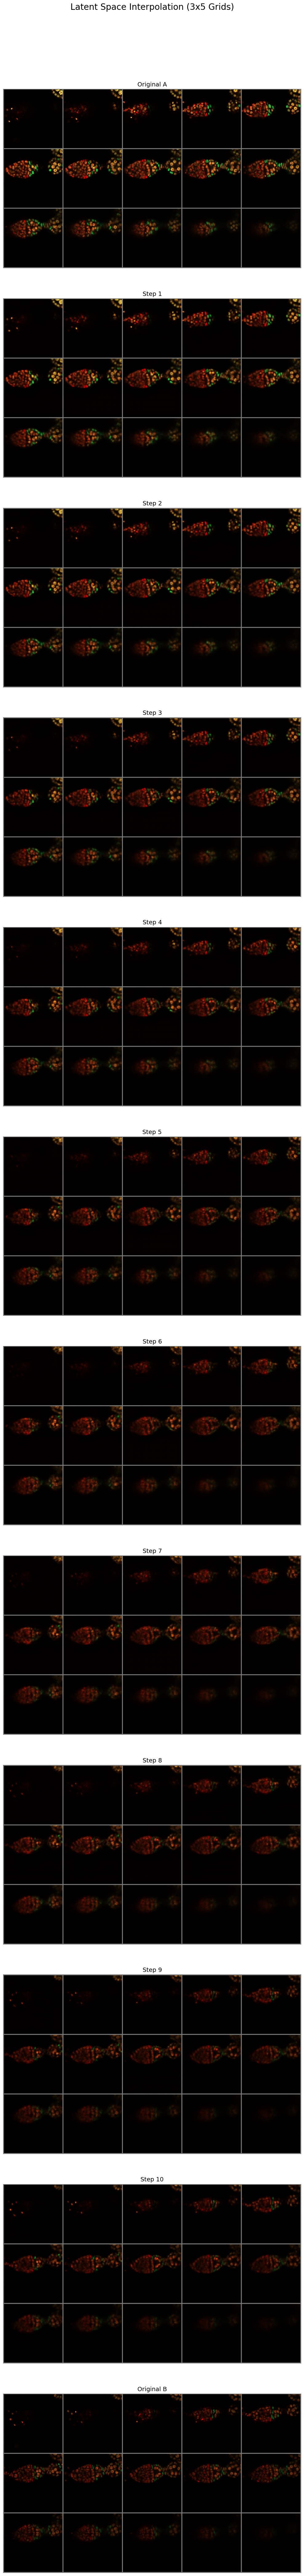

In [ ]:
interpolate_latent_space()

In [ ]:
print("test")

test


In [ ]:
model

VAE(
  (encoder): Sequential(
    (0): Conv3d(3, 64, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1))
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Conv3d(64, 128, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=(1, 1, 1))
    (4): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): SiLU()
    (6): Conv3d(128, 256, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
    (7): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): SiLU()
    (9): Conv3d(256, 512, kernel_size=(4, 3, 3), stride=(2, 1, 1), padding=(0, 1, 1))
    (10): BatchNorm3d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): SiLU()
    (12): Conv3d(512, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
  (decoder): Sequential(
    (0): ConvTranspose3d(16, 512, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 

In [ ]:
"""import torch
import matplotlib.pyplot as plt

# Generate samples from random latent vectors
n = 8  # Reduced number for 256x256 images
z = torch.randn(n, latent_dim).to(device)  # Use full latent_dim (128)
samples = model.decode(z)

# Convert to numpy for plotting
samples_np = samples.cpu().detach().numpy()

# Plot the generated images
fig, ax = plt.subplots(1, n, figsize=(16, 2))
for i in range(n):
    # Convert from (C, H, W) to (H, W, C) for matplotlib
    img = samples_np[i].transpose(1, 2, 0)
    ax[i].imshow(img)
    ax[i].axis('off')
    ax[i].set_title(f'Sample {i+1}')

plt.tight_layout()
plt.savefig('vae_germarium_samples.png', dpi=150, bbox_inches='tight')
plt.show()"""

"import torch\nimport matplotlib.pyplot as plt\n\n# Generate samples from random latent vectors\nn = 8  # Reduced number for 256x256 images\nz = torch.randn(n, latent_dim).to(device)  # Use full latent_dim (128)\nsamples = model.decode(z)\n\n# Convert to numpy for plotting\nsamples_np = samples.cpu().detach().numpy()\n\n# Plot the generated images\nfig, ax = plt.subplots(1, n, figsize=(16, 2))\nfor i in range(n):\n    # Convert from (C, H, W) to (H, W, C) for matplotlib\n    img = samples_np[i].transpose(1, 2, 0)\n    ax[i].imshow(img)\n    ax[i].axis('off')\n    ax[i].set_title(f'Sample {i+1}')\n\nplt.tight_layout()\nplt.savefig('vae_germarium_samples.png', dpi=150, bbox_inches='tight')\nplt.show()"

In [ ]:
# Recreate the model with the updated VAE class
model = VAE(input_channels=3, latent_channels=latent_channels).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
model = torch.compile(model)

print("Model recreated with 3D-to-2D LPIPS support and proper device handling")
print(f"Model device: {next(model.parameters()).device}")
print(f"LPIPS device: {next(loss_fn_vgg.parameters()).device}")

Model recreated with 3D-to-2D LPIPS support and proper device handling
Model device: cuda:0
LPIPS device: cuda:0


In [ ]:
# Test the updated model with dummy data
dummy_data = torch.randn(2, 3, 15, 128, 128).to(device)

model.eval()
with torch.no_grad():
    # Test forward pass without loss
    output_no_loss = model(dummy_data, compute_loss=False)
    print('Forward pass without loss - SUCCESS')
    print(f'Input shape: {dummy_data.shape}')
    print(f'Output shape: {output_no_loss.x_recon.shape}')
    
    # Test forward pass with loss (including LPIPS)
    output_with_loss = model(dummy_data, compute_loss=True, beta=1.0)
    print('Forward pass with LPIPS loss - SUCCESS')
    print(f'Total loss: {output_with_loss.loss.item():.4f}')
    print(f'Reconstruction loss: {output_with_loss.loss_recon.item():.4f}')
    print(f'KL loss: {output_with_loss.loss_kl.item():.4f}')

print("\\n✅ Model successfully handles 3D volumes with LPIPS on each 2D slice!")

Forward pass without loss - SUCCESS
Input shape: torch.Size([2, 3, 15, 128, 128])
Output shape: torch.Size([2, 3, 15, 128, 128])
Forward pass with LPIPS loss - SUCCESS
Total loss: 198165.4375
Reconstruction loss: 198165.1875
KL loss: 0.2469
\n✅ Model successfully handles 3D volumes with LPIPS on each 2D slice!
